import pandas as pd
df = pd.read_csv("/content/Bengaluru_House_Data.csv")

df.head()
df.shape


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [9]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [11]:
df.duplicated().sum()

np.int64(529)

In [12]:
df[df.duplicated()].head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
971,Super built-up Area,Ready To Move,Haralur Road,3 BHK,NRowse,1464,3.0,2.0,56.0
1115,Super built-up Area,Ready To Move,Haralur Road,2 BHK,NaN,1027,2.0,2.0,44.0
1143,Super built-up Area,Ready To Move,Vittasandra,2 BHK,Prlla C,1246,2.0,1.0,64.5
1290,Super built-up Area,Ready To Move,Haralur Road,2 BHK,NaN,1194,2.0,2.0,47.0
1394,Super built-up Area,Ready To Move,Haralur Road,2 BHK,NaN,1027,2.0,2.0,44.0


In [19]:
df = df.drop_duplicates()
df.shape

(12791, 9)

In [20]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
area_type,0.00
availability,0.00
location,0.01
size,0.13
society,41.65
total_sqft,0.00
bath,0.57
balcony,4.73
price,0.00


In [21]:
df['society'].head(10)

,society
0,Coomee
1,Theanmp
2,NaN
3,Soiewre
4,NaN
5,DuenaTa
6,Jaades
7,Brway G
8,NaN
9,NaN


In [22]:
df['size'].value_counts().head(15)

,count
size,
2 BHK,4931
3 BHK,4120
4 Bedroom,824
4 BHK,574
3 Bedroom,535
1 BHK,521
2 Bedroom,314
5 Bedroom,291
6 Bedroom,191


In [24]:
df['bhk'] = df['size'].str.split().str[0].astype(float)
df[['size', 'bhk']].head(10)

,size,bhk
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0
5,2 BHK,2.0
6,4 BHK,4.0
7,4 BHK,4.0
8,3 BHK,3.0
9,6 Bedroom,6.0


In [26]:
df['bhk'].isnull().sum()
df[df['bhk'].isnull()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
579,Plot Area,Immediate Possession,Sarjapur Road,NaN,Asiss B,1200 - 2400,NaN,NaN,34.185,NaN
1775,Plot Area,Immediate Possession,IVC Road,NaN,Orana N,2000 - 5634,NaN,NaN,124.000,NaN
2264,Plot Area,Immediate Possession,Banashankari,NaN,NaN,2400,NaN,NaN,460.000,NaN
2809,Plot Area,Immediate Possession,Sarjapur Road,NaN,AsdiaAr,1200 - 2400,NaN,NaN,28.785,NaN
2862,Plot Area,Immediate Possession,Devanahalli,NaN,Ajleyor,1500 - 2400,NaN,NaN,46.800,NaN
5333,Plot Area,Immediate Possession,Devanahalli,NaN,Emngs S,2100 - 5405,NaN,NaN,177.115,NaN
6423,Plot Area,Immediate Possession,Whitefield,NaN,SRniaGa,2324,NaN,NaN,26.730,NaN
6636,Plot Area,Immediate Possession,Jigani,NaN,S2enste,1500,NaN,NaN,25.490,NaN
6719,Plot Area,Immediate Possession,Hoskote,NaN,SJowsn,800 - 2660,NaN,NaN,28.545,NaN
7680,Plot Area,Immediate Possession,Kasavanhalli,NaN,NaN,5000,NaN,NaN,400.000,NaN


In [28]:
df['total_sqft'].dtype
df['total_sqft'].head(20)

,total_sqft
0,1056
1,2600
2,1440
3,1521
4,1200
5,1170
6,2732
7,3300
8,1310
9,1020


In [30]:
df['total_sqft'].apply(type).value_counts()
df['total_sqft'].astype(str).str.contains('-').sum()

np.int64(200)

In [31]:
df[df['total_sqft'].astype(str).str.contains('-')]['total_sqft'].head(20)

,total_sqft
30,2100 - 2850
56,3010 - 3410
81,2957 - 3450
122,3067 - 8156
137,1042 - 1105
165,1145 - 1340
188,1015 - 1540
224,1520 - 1740
549,1195 - 1440
579,1200 - 2400


In [37]:
df[~df['total_sqft'].astype(str).str.match(r'^\d+(\.\d+)?$')]['total_sqft'].value_counts().head(30)

,count
total_sqft,
2830 - 2882,4
1200 - 2400,3
3630 - 3800,3
2249.81 - 4112.19,3
4000 - 5249,2
1115 - 1130,2
613 - 648,2
1430 - 1630,2
645 - 936,2


In [39]:
df[df['total_sqft'].astype(str).str.contains('[A-Za-z]', regex=True)]['total_sqft'].value_counts()

,count
total_sqft,
142.61Sq. Meter,2
4125Perch,1
1000Sq. Meter,1
1100Sq. Yards,1
34.46Sq. Meter,1
5.31Acres,1
30Acres,1
716Sq. Meter,1
1500Sq. Meter,1


In [43]:
def convert_sqft(x):
    x = str(x).strip()

    if '-' in x:
        parts = x.split('-')
        return (float(parts[0]) + float(parts[1])) / 2

    elif 'Sq. Meter' in x:
        return float(x.replace('Sq. Meter', '').strip()) * 10.7639

    elif 'Sq. Yards' in x:
        return float(x.replace('Sq. Yards', '').strip()) * 9

    elif 'Acres' in x:
        return float(x.replace('Acres', '').strip()) * 43560

    elif 'Cents' in x:
        return float(x.replace('Cents', '').strip()) * 435.6

    elif 'Guntha' in x:
        return float(x.replace('Guntha', '').strip()) * 1089

    elif 'Grounds' in x:
        return float(x.replace('Grounds', '').strip()) * 2400

    elif 'Perch' in x:
        return float(x.replace('Perch', '').strip()) * 272.25

    else:
        return float(x)

df['total_sqft_num'] = df['total_sqft'].apply(convert_sqft)
df[['total_sqft', 'total_sqft_num']].head(20)

,total_sqft,total_sqft_num
0,1056,1056.0
1,2600,2600.0
2,1440,1440.0
3,1521,1521.0
4,1200,1200.0
5,1170,1170.0
6,2732,2732.0
7,3300,3300.0
8,1310,1310.0
9,1020,1020.0


In [44]:
df['total_sqft_num'].isnull().sum()

np.int64(0)

In [45]:
df['bath'].isnull().sum()

np.int64(73)

In [46]:
df[df['bath'].isnull()][['size', 'bhk', 'total_sqft_num', 'price']].head(20)

,size,bhk,total_sqft_num,price
56,4 Bedroom,4.0,3210.0,192.000
81,4 Bedroom,4.0,3203.5,224.500
224,3 BHK,3.0,1630.0,74.820
344,1 BHK,1.0,525.0,21.530
579,NaN,NaN,1800.0,34.185
669,5 BHK,5.0,5520.0,375.000
702,5 BHK,5.0,5600.0,548.500
801,4 BHK,4.0,4624.5,453.000
941,4 Bedroom,4.0,4348.5,304.000
1264,3 Bedroom,3.0,2264.0,155.000


In [48]:
df = df.dropna(subset=['bath'])
df['bath'].isnull().sum()

np.int64(0)

In [50]:
df['balcony'].isnull().sum()
df['balcony'].value_counts(dropna=False)

,count
balcony,
2.0,4846
1.0,4700
3.0,1630
0.0,1010
NaN,532


In [51]:
df['balcony'].median()

2.0

In [52]:
df['balcony'] = df['balcony'].fillna(2)
df['balcony'].isnull().sum()

np.int64(0)

In [53]:
df['location'].isnull().sum()

np.int64(1)

In [55]:
df = df.dropna(subset=['location'])
df['location'].isnull().sum()

np.int64(0)

In [56]:
df['society'] = df['society'].fillna('Unknown')
df['society'].isnull().sum()

np.int64(0)

In [57]:
df.duplicated().sum()

np.int64(1)

In [58]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [59]:
df['price'].describe()

,price
count,12716.000000
mean,114.149621
std,151.609078
min,8.000000
25%,50.000000
50%,73.000000
75%,120.000000
max,3600.000000


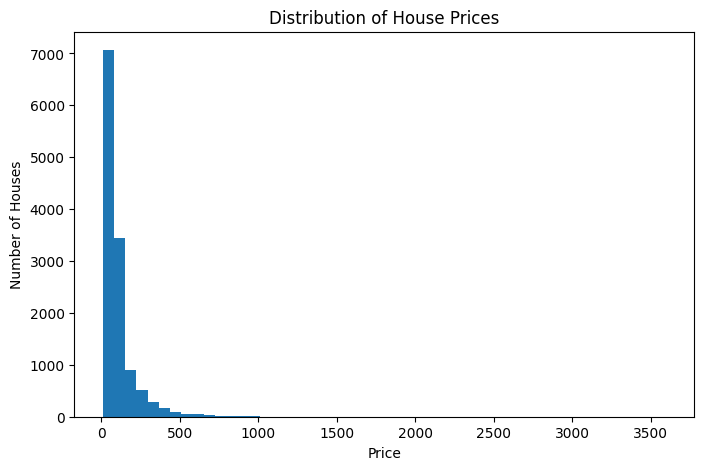

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.title('Distribution of House Prices')
plt.show()

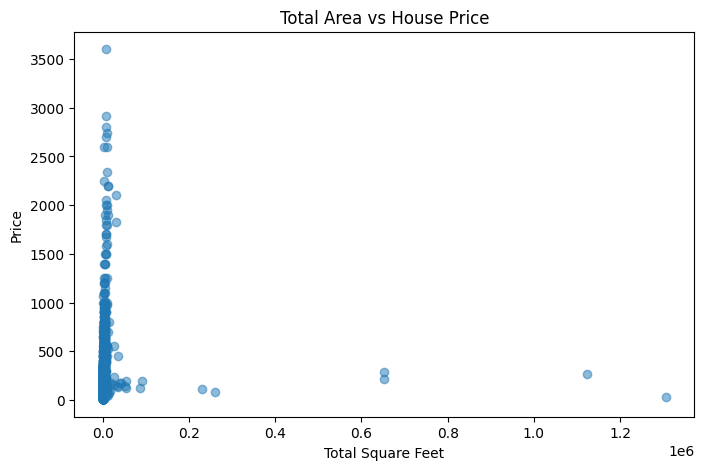

In [61]:
plt.figure(figsize=(8,5))
plt.scatter(df['total_sqft_num'], df['price'], alpha=0.5)
plt.xlabel('Total Square Feet')
plt.ylabel('Price')
plt.title('Total Area vs House Price')
plt.show()

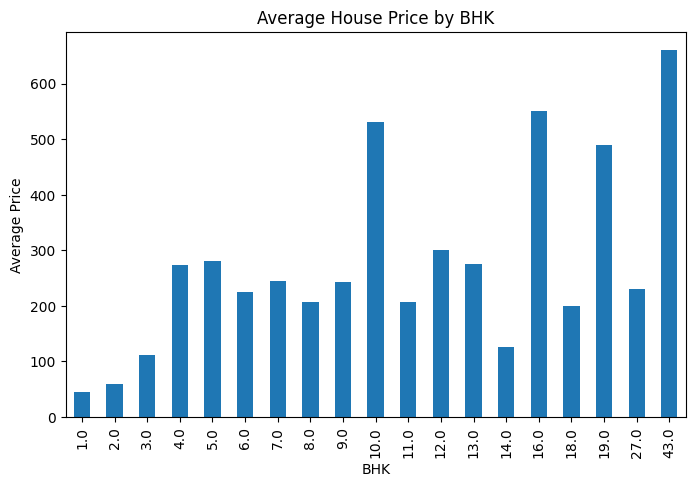

In [62]:
plt.figure(figsize=(8,5))
df.groupby('bhk')['price'].mean().plot(kind='bar')
plt.xlabel('BHK')
plt.ylabel('Average Price')
plt.title('Average House Price by BHK')
plt.show()

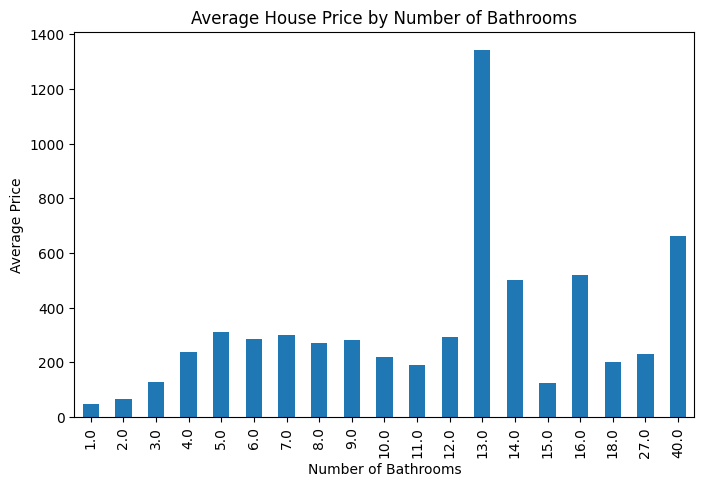

In [63]:
plt.figure(figsize=(8,5))
df.groupby('bath')['price'].mean().plot(kind='bar')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Average Price')
plt.title('Average House Price by Number of Bathrooms')
plt.show()

In [64]:
X = df[['total_sqft_num', 'bhk', 'bath', 'balcony']]
y = df['price']

X.head()

,total_sqft_num,bhk,bath,balcony
0,1056.0,2.0,2.0,1.0
1,2600.0,4.0,5.0,3.0
2,1440.0,3.0,2.0,3.0
3,1521.0,3.0,3.0,1.0
4,1200.0,2.0,2.0,1.0


In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((10172, 4), (2544, 4))

In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [70]:
y_pred = model.predict(X_test)
y_pred[:10]

array([135.58608892,  81.71794811,  81.7270566 , 135.50456795,
        81.69912391,  76.29912861,  71.23402205,  76.28136705,
        81.7138493 , 124.74829809])

In [71]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mae

59.596089682425465

In [72]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(y_test, y_pred) ** 0.5
rmse

152.7634602090724

In [73]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
r2

0.1668129827703584

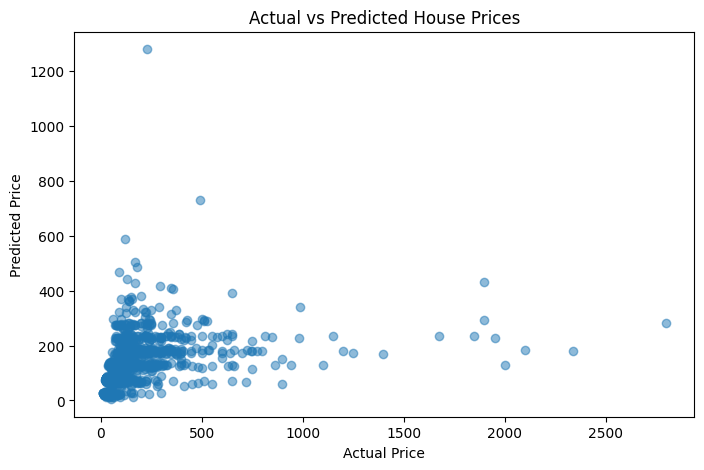

In [74]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

In [75]:
df['location'].nunique()

1304

In [76]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred))

MAE: 59.596089682425465
RMSE: 152.7634602090724
R² Score: 0.1668129827703584
